In [15]:
print("hello")

hello


In [16]:
import pathlib

# define an output path
output_path = pathlib.Path("./output")
# Create the output path
output_path.mkdir(exist_ok=True)

# Define database path
database_path = output_path / "database.db"

In [17]:
import pycolmap

# Defined the image directory
image_dir = pathlib.Path("./input/01_lego_small")

# Extract Features
pycolmap.extract_features(database_path, image_dir, camera_model='OPENCV')

In [18]:
# Load the database
#db = pycolmap.Database(database_path)
#db.num_keypoints

In [19]:
import pycolmap
import numpy as np

# Open the database
db = pycolmap.Database(database_path)

# Get all images from the database
images = db.read_all_images()

# Check if there are any images
if images:
    # Get the first image id from the list of images
    first_image_id = images[0].image_id
    
    # Get the image object
    first_image = images[0]
    
    # Get the keypoints for the first image
    keypoints = db.read_keypoints(first_image_id)
    
    print(f"Features for image: {first_image.name}")
    print(f"Number of keypoints: {len(keypoints)}")
    
    # Print the first 5 keypoints
    print("First 5 keypoints (x, y, scale, orientation):")
    for i in range(min(5, len(keypoints))):
        kp = keypoints[i]
        print(f"  {i+1}: (x={kp[0]:.2f}, y={kp[1]:.2f}, scale={kp[2]:.2f}, orientation={kp[3]:.2f})")
else:
    print("No images found in the database.")

Features for image: r_0.png
Number of keypoints: 2440
First 5 keypoints (x, y, scale, orientation):
  1: (x=366.66, y=115.25, scale=-1.01, orientation=0.56)
  2: (x=366.66, y=115.25, scale=0.90, orientation=0.72)
  3: (x=330.55, y=116.23, scale=-0.73, orientation=0.76)
  4: (x=315.94, y=117.40, scale=-0.63, orientation=0.61)
  5: (x=311.81, y=120.21, scale=-0.26, orientation=0.86)


In [20]:
# Get the descriptors for the first image
descriptors = db.read_descriptors(first_image_id)

print(f"Shape of descriptors array: {descriptors.shape}")

# Print the first 2 descriptors
print("First 2 descriptors:")
for i in range(min(2, len(descriptors))):
    desc = descriptors[i]
    print(f"  {i+1}: {desc}")

Shape of descriptors array: (2440, 128)
First 2 descriptors:
  1: [  2   3  38  80  30  15   7   5  33   1  34  95  65  22  13  45  81  13
  39  48  26  11  39 105  22   8  14  12  19  22  79  80  10   5   7  36
  35  69  61  19  66  14   3  28  48  94  52  44 105  68  20  10  13  25
  26  78  34  35  26  30  26  12  16  42  10   4   2   1   0  65  95  35
  27   8   0   0   6 101 105  26  76  46  10   2   2  41  92  86  37  26
  23  17   2   1  36  90  22   7   7   2   1  27  48  33   6   2  12  16
   5  44  82  25   5   5  54  70   2  22  78  62   9   8 105 105   0   0
  27  52]
  2: [ 26  34  26   6   9  14  30  18   2  59  57  32  26  19  16   5  17  86
  61  19   8  69  28   0  15  44  13   4  11 110  84   0  26  90 104  35
  17  15  19  15  25  35 100 110  41  17  12  11  97  96  63  49   9   1
   1  15  69  64  10   3   9  44  15   5  11  68 106  22  22  67  68  25
  64  33  93  61   2  11  46  63 110  44  24  20   0   0   3  52  85  49
  17   6   3   2   1   5  10  26   6   4   

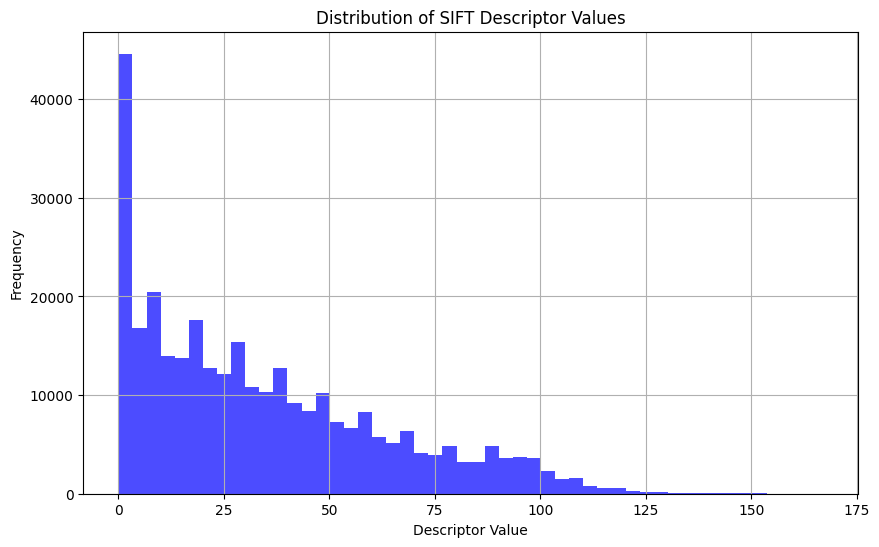

In [21]:
import matplotlib.pyplot as plt

# Flatten the descriptors array to get a 1D array of all descriptor values
descriptor_values = descriptors.flatten()

# Plot a histogram of the descriptor values
plt.figure(figsize=(10, 6))
plt.hist(descriptor_values, bins=50, color='blue', alpha=0.7)
plt.title('Distribution of SIFT Descriptor Values')
plt.xlabel('Descriptor Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

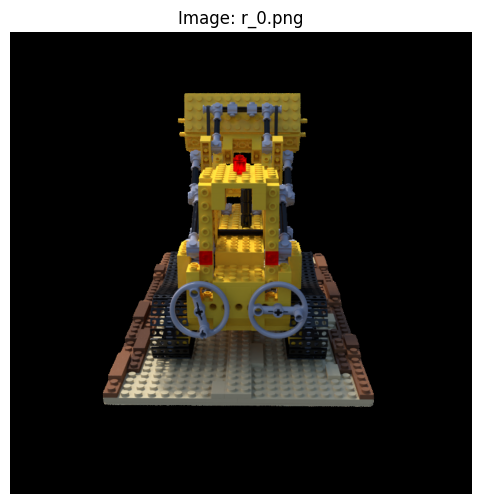

In [22]:
import matplotlib.pyplot as plt
import cv2
import pathlib

# Get the image directory and list images
image_dir = pathlib.Path("./input/01_lego_small")
image_files = sorted(image_dir.glob("*.png"))

if image_files:
    # Load the first image
    img_path = image_files[0]
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title(f"Image: {img_path.name}")
    plt.axis('off')
    plt.show()
else:
    print("No images found in input/01_lego_small directory.")

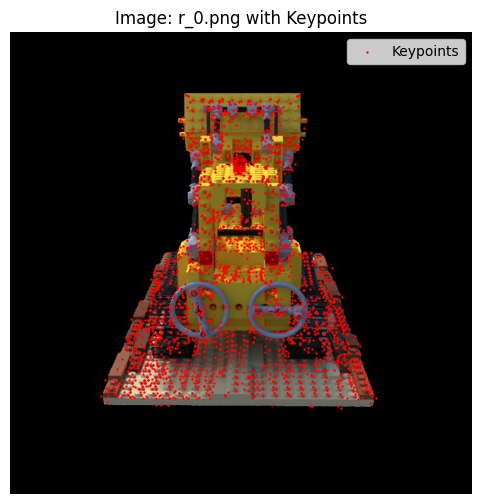

In [23]:
import matplotlib.pyplot as plt
import cv2
import pathlib

# Get the image directory and list images
image_dir = pathlib.Path("./input/01_lego_small")
image_files = sorted(image_dir.glob("*.png"))

if image_files:
    # Load the first image
    img_path = image_files[0]
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Overlay keypoints
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.scatter(keypoints[:, 0], keypoints[:, 1], s=0.5, c='red', marker='o', label='Keypoints')
    plt.title(f"Image: {img_path.name} with Keypoints")
    plt.axis('off')
    plt.legend()
    plt.show()
else:
    print("No images found in input/01_lego_small directory.")

In [24]:
# Feature Matching
pycolmap.match_exhaustive(database_path)

In [25]:
# Read the matches from the database
pair_ids, all_matches = db.read_all_matches()

print(f"Number of image pairs with matches: {len(pair_ids)}")

# Print some matches for the first pair
if pair_ids:
    # Get the first pair_id
    first_pair_id = pair_ids[0]
    
    # Convert pair_id to image_ids
    image_id1, image_id2 = pycolmap.Database.pair_id_to_image_pair(first_pair_id)
    
    # Get the matches for this pair
    image_pair_matches = all_matches[0]
    
    # Get the images
    images = db.read_all_images()
    image_map = {im.image_id: im for im in images}
    
    # Check if image_id1 and image_id2 are in image_map
    if image_id1 in image_map and image_id2 in image_map:
        print(f"\nMatches between image {image_map[image_id1].name} and image {image_map[image_id2].name}:")
        print(f"Number of matches: {len(image_pair_matches)}")
        
        # Print the first 5 matches
        print("First 5 matches (keypoint_index1, keypoint_index2):")
        for i in range(min(5, len(image_pair_matches))):
            kp_idx1, kp_idx2 = image_pair_matches[i]
            print(f"  {i+1}: ({kp_idx1}, {kp_idx2})")
    else:
        print("Could not find image names for the matched pair.")

Number of image pairs with matches: 1131

Matches between image r_0.png and image r_1.png:
Number of matches: 68
First 5 matches (keypoint_index1, keypoint_index2):
  1: (16, 10)
  2: (17, 783)
  3: (56, 65)
  4: (81, 106)
  5: (188, 2044)


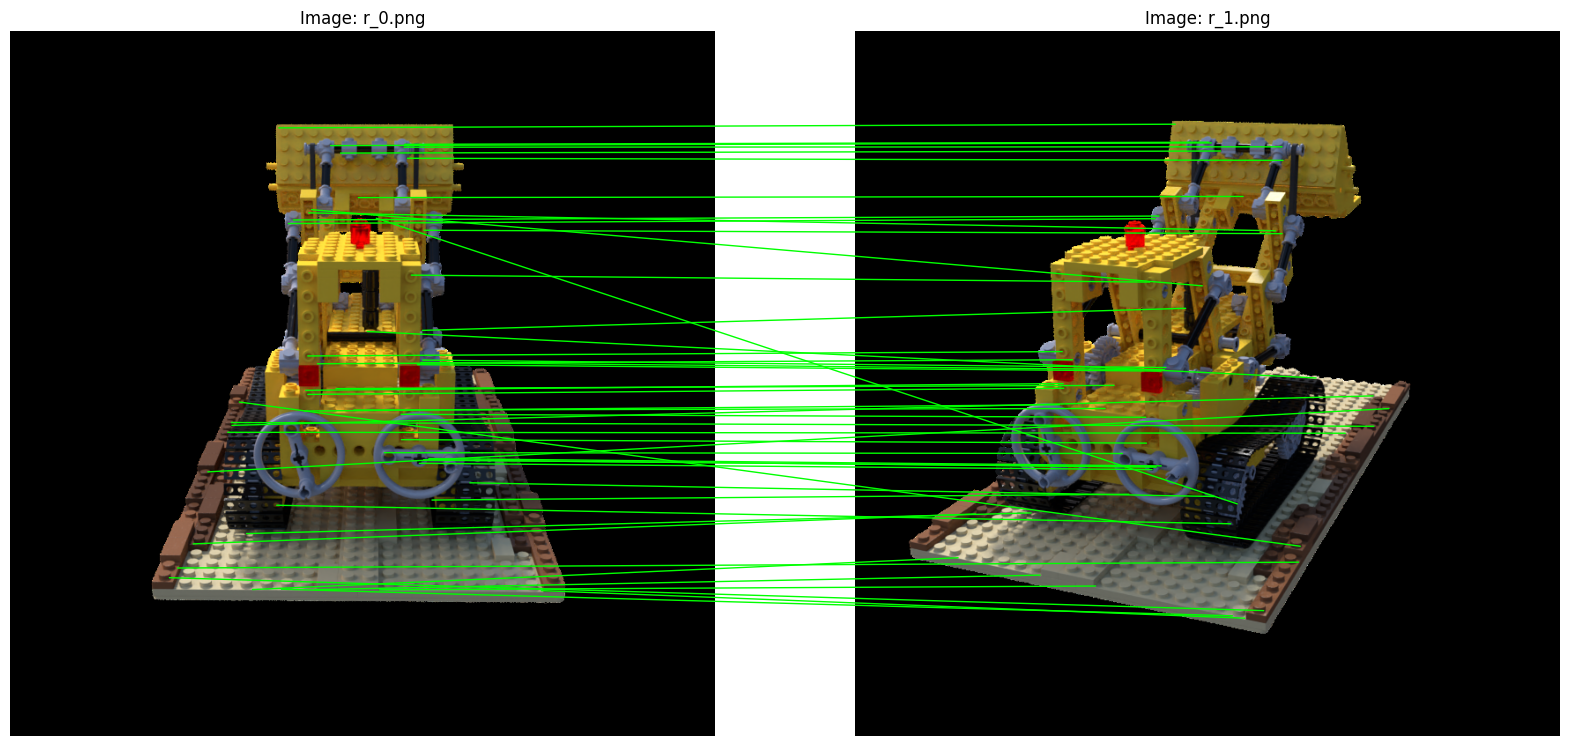

In [26]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import ConnectionPatch

# This code reuses variables from the previous cell:
# pair_ids, all_matches, db, image_dir

if pair_ids:
    # Get the first pair of matched images
    first_pair_id = pair_ids[0]
    image_id1, image_id2 = pycolmap.Database.pair_id_to_image_pair(first_pair_id)
    
    # Get the matches for this pair
    image_pair_matches = all_matches[0]
    
    # Get image names and paths
    images = db.read_all_images()
    image_map = {im.image_id: im for im in images}
    
    if image_id1 in image_map and image_id2 in image_map:
        img_name1 = image_map[image_id1].name
        img_name2 = image_map[image_id2].name
        
        img_path1 = image_dir / img_name1
        img_path2 = image_dir / img_name2
        
        # Load images
        img1 = cv2.imread(str(img_path1))
        img2 = cv2.imread(str(img_path2))
        img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
        img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
        
        # Get keypoints
        keypoints1 = db.read_keypoints(image_id1)
        keypoints2 = db.read_keypoints(image_id2)
        
        # Create a figure with two subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
        
        # Display images
        ax1.imshow(img1_rgb)
        ax1.set_title(f"Image: {img_name1}")
        ax1.axis('off')
        
        ax2.imshow(img2_rgb)
        ax2.set_title(f"Image: {img_name2}")
        ax2.axis('off')
        
        # Draw lines for the first 50 matches
        for i in range(min(50, len(image_pair_matches))):
            kp_idx1, kp_idx2 = image_pair_matches[i]
            
            # Get keypoint coordinates
            pt1 = keypoints1[kp_idx1][:2]
            pt2 = keypoints2[kp_idx2][:2]
            
            # Create a connection patch
            con = ConnectionPatch(xyA=pt2, xyB=pt1, coordsA=ax2.transData, coordsB=ax1.transData,
                                  color=(0,1,0), linewidth=1)
            fig.add_artist(con)

        plt.show()
    else:
        print("Could not find image names for the matched pair.")
else:
    print("No matches found in the database.")

In [27]:
maps = pycolmap.incremental_mapping(database_path, image_dir, output_path)

In [28]:
maps

{0: Reconstruction(num_rigs=5, num_cameras=5, num_frames=5, num_reg_frames=5, num_images=5, num_points3D=1068),
 1: Reconstruction(num_rigs=37, num_cameras=37, num_frames=37, num_reg_frames=37, num_images=37, num_points3D=4029),
 2: Reconstruction(num_rigs=11, num_cameras=11, num_frames=11, num_reg_frames=11, num_images=11, num_points3D=679),
 3: Reconstruction(num_rigs=10, num_cameras=10, num_frames=10, num_reg_frames=10, num_images=10, num_points3D=793)}

In [36]:
maps[0].points3D

Point3DMap{1: Point3D(xyz=[1.48485, -1.20778, 14.7349], track_len=3), 944: Point3D(xyz=[-0.543535, -0.908897, 14.488], track_len=2), 393: Point3D(xyz=[2.38464, 2.12511, 15.5017], track_len=4), 1054: Point3D(xyz=[1.97813, 1.24005, 15.8939], track_len=2), 2: Point3D(xyz=[0.826789, 0.225359, 10.0067], track_len=2), 3: Point3D(xyz=[1.56346, 1.26184, 15.8154], track_len=2), 1064: Point3D(xyz=[2.29458, 1.4233, 16.1133], track_len=3), 387: Point3D(xyz=[4.26195, 1.64859, 15.6443], track_len=4), 4: Point3D(xyz=[2.03368, 1.75501, 16.278], track_len=3), 5: Point3D(xyz=[-1.05794, 2.08705, 15.4898], track_len=4), 1066: Point3D(xyz=[2.7933, 1.4922, 16.0692], track_len=2), 397: Point3D(xyz=[2.38887, 2.29093, 15.4502], track_len=4), 6: Point3D(xyz=[0.340414, 2.84655, 15.0765], track_len=3), 7: Point3D(xyz=[0.340414, 2.84655, 15.0765], track_len=3), 8: Point3D(xyz=[0.699873, -0.740428, 15.7148], track_len=5), 9: Point3D(xyz=[-0.895537, -0.460438, 15.9993], track_len=2), 952: Point3D(xyz=[1.9758, 0.9606